- [1단계: 실시간 데이터 로더 (PyTorch3D)]
<br> - 무작위 도형 조합 생성 
<br> - 가상 카메라 2~3대 배치 후 이미지 렌더링 -> 입력 데이터 (Image 2~3)
<br> - 해당 도형의 실제 3D 좌표 추출 -> 정답 데이터 (GT Point Cloud)
- [2단계: 경량 3D 재구성 모델 (우리 모델)]
<br> - 입력(Image 2~3) → 경량 2D 인코더 → 가벼운 3D 디코더
<br> - 출력: 예측된 3D 포인트 클라우드 (Pred Point Cloud)
- [3단계: SimpleNet 방식의 이상 탐지 학습]
<br> - 진짜 정답(GT Point Cloud) 추출
<br> - [정상 데이터]로 취급하여 학습
<br> - 여기에 가우시안 노이즈를 섞어 분포를 비튼 [가짜 불량 데이터] 생성
<br> - 판별기(Discriminator)가 진짜 정답과 가짜 노이즈 데이터를 구분하도록 학습

##### [1단계: 실시간 데이터 로더 (PyTorch3D)]

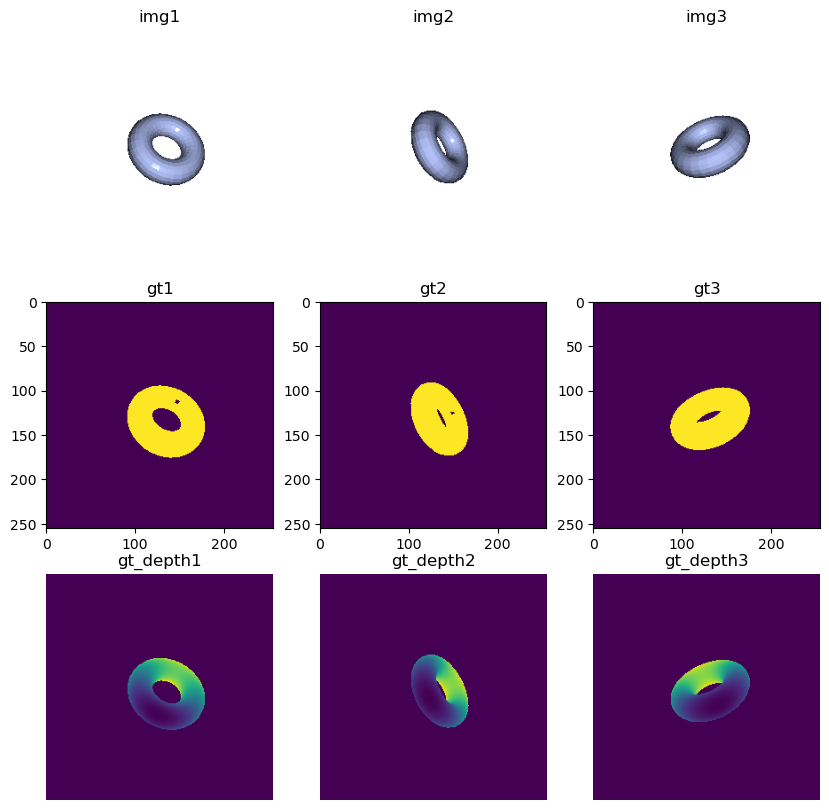

In [1]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import trimesh
import torch
import cv2

# 1개의 랜덤한 도형
def generate_random_geometry(mode="easy"):
    """1.
       무작위 도형(구, 상자, 실린더 중 하나)을 생성하고, 다각도 이미지 3장을 렌더링합니다.
    """
    # 결합할 빈 메쉬 생성
    combined_mesh = o3d.geometry.TriangleMesh()

    if mode == "easy": num_blocks = 1
    # 3개에서 5개 사이의 무작위 블록을 쌓음
    elif mode == "hard": num_blocks = np.random.randint(1, 4)
              
    for _ in range(num_blocks):
        # 무작위 도형 선택
        geom_type = np.random.choice(["cube", "sphere", "cylinder", "cone", "torus",])
        # geom_type = np.random.choice(["cube", "sphere", "cylinder",])
        if geom_type == "cube":
            w = np.random.uniform(0.6, 1.4)
            h = np.random.uniform(0.6, 1.4)
            d = np.random.uniform(0.6, 1.4)
            mesh = o3d.geometry.TriangleMesh.create_box(width=w, height=h, depth=d)
        elif geom_type == "sphere":
            r = np.random.uniform(0.4, 0.9)
            mesh = o3d.geometry.TriangleMesh.create_sphere(radius=r)
        elif geom_type == "cylinder":
            r = np.random.uniform(0.25, 0.6)
            h = np.random.uniform(0.8, 1.6)
            mesh = o3d.geometry.TriangleMesh.create_cylinder(radius=r, height=h)
            mesh.translate(-mesh.get_center())
        elif geom_type == "cone":
            r = np.random.uniform(0.3, 0.7)
            h = np.random.uniform(0.8, 1.8)
            mesh = o3d.geometry.TriangleMesh.create_cone(radius=r, height=h)
            mesh.translate(-mesh.get_center())

        elif geom_type == "torus":
            torus_radius = np.random.uniform(0.6, 1.2)
            tube_radius = np.random.uniform(0.15, 0.35)
            mesh = o3d.geometry.TriangleMesh.create_torus(
                torus_radius=torus_radius,
                tube_radius=tube_radius
            )

        # 블록을 무작위 위치로 이동 (X, Y, Z 각각 -0.4 ~ 0.4 범위)
        random_translation = np.random.uniform(-0.4, 0.4, 3)
        mesh.translate(random_translation)
        
        # 블록에 무작위 회전 적용
        R = mesh.get_rotation_matrix_from_xyz(np.random.uniform(0, np.pi, 3))
        mesh.rotate(R, center=(0, 0, 0))

        # 메쉬 합치기
        combined_mesh += mesh
        
    if mode == "easy": pass
    elif mode == "hard":
        vertices = np.asarray(combined_mesh.vertices)
        triangles = np.asarray(combined_mesh.triangles)
        tm_mesh = trimesh.Trimesh(vertices=vertices, faces=triangles)

        # [선택 A] 복합 고형 연산 (Boolean Union)
        # 얽힌 메쉬들의 내부 경계면을 완전히 녹여서 하나의 원자적 껍데기로 만듭니다.
        # 만약 에러가 발생하거나 속도가 느리다면 아래 [선택 B]로 대체하세요.
        try:
            cleaned_tm_mesh = tm_mesh.process(validate=True)
            # 겉 표면(외곽선)만 남기고 내부 분할면을 지우는 연산
            cleaned_tm_mesh = cleaned_tm_mesh.convex_hull
        except:
            # [선택 B] 체적 기반으로 외부 표면(만질 수 있는 면)만 추출
            # 완전히 밀폐된(Watertight) 외부 쉘만 남기고 내부 인프라를 통째로 날립니다.
            cleaned_tm_mesh = trimesh.repair.broken_faces(tm_mesh)
            cleaned_tm_mesh = tm_mesh.split()[
                0
            ]  # 가장 부피가 큰 외곽 덩어리만 선택

        # 3. 깨끗해진 trimesh를 다시 Open3D 메쉬 타입으로 완벽히 복원합니다.
        # 이 과정 덕분에 뒤이은 Open3D 기반 렌더링 코드가 깨지지 않습니다.
        surface_mesh = o3d.geometry.TriangleMesh()
        surface_mesh.vertices = o3d.utility.Vector3dVector(cleaned_tm_mesh.vertices)
        surface_mesh.triangles = o3d.utility.Vector3iVector(cleaned_tm_mesh.faces)

        # 원본 변수에 새 메쉬를 할당하여 기존 흐름을 유지합니다.
        combined_mesh = surface_mesh

    combined_mesh.compute_vertex_normals()
    combined_mesh.paint_uniform_color(np.random.rand(3))  # 무작위 색상

    # 가상 카메라 각도 설정 (정면, 측면, 반대측면)
    view_angles = [
        {"zoom": 1.5, "front": [0, 0, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
        {"zoom": 1.5, "front": [1, 0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
        {"zoom": 1.5, "front": [-1, -0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0],},
        ]

    images = []
    depths = []
    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False, width=256, height=256)
    vis.add_geometry(combined_mesh)
    vis.get_render_option().point_size = 3.0

    # 각 각도에서 이미지 렌더링
    ctr = vis.get_view_control()
    for angle in view_angles:
        ctr.set_zoom(angle["zoom"])
        ctr.set_front(angle["front"])
        ctr.set_lookat(angle["lookat"])
        ctr.set_up(angle["up"])
        vis.poll_events()
        vis.update_renderer()
        img = vis.capture_screen_float_buffer(do_render=True)
        depth = np.asarray(vis.capture_depth_float_buffer(do_render=True))

        # 유효 depth만 사용하여 0~1 사이로 정규화 (배경은 0 유지)
        valid = depth > 0
        if np.any(valid):
            d_min = depth[valid].min()
            d_max = depth[valid].max()

            depth[valid] = (depth[valid] - d_min) / (d_max - d_min + 1e-8)
        # background는 0 유지
        depth[~valid] = 0.0

        images.append(np.asarray(img))
        depths.append(depth)

    vis.destroy_window()
    return combined_mesh, images, depths

# def generate_random_geometry(mode="easy"):
#     """1.
#        무작위 도형(구, 상자, 실린더 중 하나)을 생성하고, 다각도 이미지 3장을 렌더링합니다.
#     """
#     # 무작위 도형 선택
#     geom_type = np.random.choice(["cube", "sphere", "cylinder"])
#     if geom_type == "cube":
#         mesh = o3d.geometry.TriangleMesh.create_box(
#             width=1.0, height=1.0, depth=1.0
#         )
#     elif geom_type == "sphere":
#         mesh = o3d.geometry.TriangleMesh.create_sphere(radius=0.6)
#     else:
#         mesh = o3d.geometry.TriangleMesh.create_cylinder(
#             radius=0.4, height=1.2
#         )

#     mesh.compute_vertex_normals()
#     mesh.paint_uniform_color(np.random.rand(3))  # 무작위 색상

#     # 가상 카메라 각도 설정 (정면, 측면, 반대측면)
#     view_angles = [
#         {"zoom": 1.5, "front": [0, 0, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
#         {"zoom": 1.5, "front": [1, 0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
#         {"zoom": 1.5, "front": [-1, -0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0],},
#         ]

#     images = []
#     vis = o3d.visualization.Visualizer()
#     vis.create_window(visible=False, width=256, height=256)
#     vis.add_geometry(mesh)
#     vis.get_render_option().point_size = 3.0

#     # 각 각도에서 이미지 렌더링
#     ctr = vis.get_view_control()
#     for angle in view_angles:
#         ctr.set_zoom(angle["zoom"])
#         ctr.set_front(angle["front"])
#         ctr.set_lookat(angle["lookat"])
#         ctr.set_up(angle["up"])
#         vis.poll_events()
#         vis.update_renderer()
#         img = vis.capture_screen_float_buffer(do_render=True)
#         images.append(np.asarray(img))

#     vis.destroy_window()
#     return mesh, images

def visualize_results(images, points):
    """3.
    생성된 2D 이미지들과 추출된 3D 포인트 클라우드를 각각 시각화합니다.
    """
    
    fig, axes = plt.subplots(1, len(images), figsize=(10, 4))
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].set_title(f"View {i+1}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

    # 3D 포인트 클라우드 시각화 (Open3D 창 팝업)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.paint_uniform_color([0, 0, 1])  # 파란색으로 표현
    print("3D 시각화 창을 띄웁니다. (창을 닫으면 프로세스가 계속됩니다.)")
    o3d.visualization.draw_geometries([pcd], width=250, height=250)

# - [1단계: 실시간 데이터 로더 (PyTorch3D)]
def create_data(data_num=1, mode="easy", draw_plots=False, num_points=1024):
    image_datas = []
    gt_2dDatas = []
    gt_3dDatas = []
    gt_depthDatas = []
    for _ in range(data_num):
        # 1. 도형 및 이미지 생성
        mesh, generated_images, depths = generate_random_geometry(mode=mode)
        
        # 2. 3D 좌표(GT) 추출
        pcd = mesh.sample_points_uniformly(number_of_points=num_points)
        gt_3dpoints = np.asarray(pcd.points)

        # 2-1. 2D 단면 히트맵 GT, Depth 히트맵 GT 생성
        gt_points = []
        for img in generated_images:
            # foreground
            binary_mask = ~np.all(img == [1, 1, 1], axis=-1)
            gt_points.append(binary_mask)
        
        gt_points = np.array(gt_points)
        depths = np.array(depths)
            
        image_datas.append(generated_images)
        gt_2dDatas.append(gt_points)
        gt_depthDatas.append(depths)
        gt_3dDatas.append(gt_3dpoints)

        # 3. 시각화 확인
        if draw_plots:
            print(f"추출된 3D 좌표 형상 (Shape): {gt_3dpoints.shape}")
            visualize_results(generated_images, gt_3dpoints)
        
    return image_datas, gt_2dDatas, gt_depthDatas, gt_3dDatas

def create_batch(batch_size=4, mode="easy"):
    """지정된 batch_size만큼 create_data를 호출하여 이미지 세트와 GT를 쌍(Pair)이 깨지지 않게 배치로
    결합합니다.
    """
    # 1. batch_size 개수만큼 한 번에 데이터 생성
    # image_datas 결과 구조: [[도형1_img1, 도형1_img2, 도형1_img3], [도형2_img1, ...], ...]
    # gt_2dDatas 결과 구조: [도형1_gt_2d_points, 도형2_gt_2d_points, ...]
    # gt_depthDatas 결과 구조: [도형1_gt_depth_map, 도형2_gt_depth_map, ...]

    image_datas, gt_2dDatas, gt_depthDatas, gt_3dDatas = create_data(data_num=batch_size, mode=mode,num_points=1024*2)
    
    batch_img1, batch_img2, batch_img3 = [], [], []
    batch_gt_2d = []
    batch_gt_3d = []
    batch_gt_depth = []

    # 2. 각 도형 세트별로 루프를 돌며 가상의 카메라별로 정렬
    for i in range(batch_size):
        # i번째 도형의 이미지 3장 세트 추출
        imgs = image_datas[i]

        # Open3D 포맷(H, W, C) -> PyTorch 포맷(C, H, W) 변환
        img1 = torch.from_numpy(imgs[0]).permute(2, 0, 1).float()
        img2 = torch.from_numpy(imgs[1]).permute(2, 0, 1).float()
        img3 = torch.from_numpy(imgs[2]).permute(2, 0, 1).float()

        batch_img1.append(img1)
        batch_img2.append(img2)
        batch_img3.append(img3)

        # i번째 도형의 GT 3D 포인트 추출
        # batch_gt.append(torch.from_numpy(gt_datas[i]).float())
        batch_gt_2d.append(torch.from_numpy(gt_2dDatas[i]).float())
        batch_gt_depth.append(torch.from_numpy(gt_depthDatas[i]).float())
        batch_gt_3d.append(torch.from_numpy(gt_3dDatas[i]).float())
    
    # 3. 최종 배치 텐서 변환 (인덱스가 완벽히 동기화됨)
    # 이제 model(img1, img2, img3)의 0번째 결과는 gt_points[0]과 완벽히 대응됩니다.
    return (
        torch.stack(batch_img1),
        torch.stack(batch_img2),
        torch.stack(batch_img3),
        torch.stack(batch_gt_2d),
        torch.stack(batch_gt_depth),
        torch.stack(batch_gt_3d),
    )

image_datas, gt_2dDatas, gt_depthDatas, gt_3dDatas = create_data(data_num=1, mode="easy", draw_plots=False, num_points=1024*2)

imgs = image_datas[0]
img1 = np.transpose(imgs[0], (2, 0, 1))[None].astype(np.float32)
img2 = np.transpose(imgs[1], (2, 0, 1))[None].astype(np.float32)
img3 = np.transpose(imgs[2], (2, 0, 1))[None].astype(np.float32)

# 손실 함수 계산을 위해 GT도 텐서로 변환 (1, M, 3)
gt_points_np = gt_2dDatas[0]
gt1 = gt_points_np[0][None].astype(np.float32)
gt2 = gt_points_np[1][None].astype(np.float32)
gt3 = gt_points_np[2][None].astype(np.float32)

gt_depth_np = gt_depthDatas[0]
gt_depth1 = gt_depth_np[0][None].astype(np.float32)
gt_depth2 = gt_depth_np[1][None].astype(np.float32)
gt_depth3 = gt_depth_np[2][None].astype(np.float32)

gt_3d_np = gt_3dDatas[0]
gt_3d1 = gt_3d_np[0][None].astype(np.float32)
gt_3d2 = gt_3d_np[1][None].astype(np.float32)
gt_3d3 = gt_3d_np[2][None].astype(np.float32)

imgs_vis = [img1, img2, img3]
gts_vis = [gt1, gt2, gt3]
gts_depth_vis = [gt_depth1, gt_depth2, gt_depth3]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    # Image
    img = np.transpose(imgs_vis[i][0], (1, 2, 0))

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"img{i+1}")
    axes[0, i].axis("off")

    # GT 0~1
    gt = gts_vis[i][0].reshape(-1, 2)
    axes[1, i].imshow(gts_vis[i][0])

    axes[1, i].invert_yaxis()
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_ylim(255, 0)
    axes[1, i].set_title(f"gt{i+1}")

    # GT Depth 0~1 0에 가까울수록 가깝고 1에 가까울수록 멀어지는 형태
    axes[2, i].imshow(gts_depth_vis[i][0], cmap="viridis")
    axes[2, i].set_title(f"gt_depth{i+1}")
    axes[2, i].axis("off") 

In [5]:
# - [2단계: 경량 3D 재구성 모델] 
import torch.nn as nn
import copy
import torch.nn.functional as F

class Light3DReconstructModel(nn.Module):

    def __init__(self, num_output_points=1024):
        super().__init__()
        self.num_output_points = num_output_points

        def feature_extractor():
            extractor = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 128x128
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64x64
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 32x32
                nn.BatchNorm2d(128),
                nn.ReLU(),
            )
            return extractor
        
        def feature_aggregator(feat_dim, geom_dim):
            aggregator = nn.Sequential(
                nn.Conv2d(feat_dim + geom_dim, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),

                nn.Conv2d(32, 16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                
                # 각 뷰의 독립적인 로컬 입체감을 한 번 더 정제
                nn.Conv2d(16, 8, kernel_size=3, padding=1),
                nn.BatchNorm2d(8),
                nn.ReLU()
            )
            return aggregator
        
        # 1. 초경량 커스텀 2D CNN 백본
        # 입력: (Batch, 3, 256, 256) -> 출력: (Batch, 128, 16, 16)
        self.feature_extractor1 = feature_extractor()
        self.feature_extractor2 = feature_extractor()
        
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        # 미세한 요철과 텍스처 깊이감을 돋보이게 하는 Laplacian 커널
        laplacian = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=torch.float32).view(1, 1, 3, 3)
        
        # 가중치가 학습되지 않도록 고정 (Parameter 0개 효과)
        self.register_buffer('kernel_x', sobel_x)
        self.register_buffer('kernel_y', sobel_y)
        self.register_buffer('kernel_lap', laplacian)
        
        feat_dim=128
        geom_dim=3
        self.agg1 = feature_aggregator(feat_dim, geom_dim)
        self.agg2 = feature_aggregator(feat_dim, geom_dim)
        
        def feature_adaptor():
            extractor = nn.Sequential(
                nn.Conv2d(24, 16, kernel_size=3, stride=2, padding=1), # (Batch, 16, 16, 16)
                nn.BatchNorm2d(16),
                nn.ReLU(),

                nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1), # (Batch, 8, 8, 8)
                nn.BatchNorm2d(8),
                nn.ReLU(),

                nn.Flatten(),
                nn.Linear(8 * 8 * 8, num_output_points * 2),
                nn.ReLU(),
            )
            return extractor

        def decoder_layer():
            decoder = nn.Sequential(
                nn.Flatten(),
                nn.Linear(num_output_points * 2, num_output_points),
                nn.ReLU(),
                nn.Linear(num_output_points, num_output_points * 3),  # (1024 * 3)
            )
            return decoder
        
        def spread_layer():
            decoder = nn.Sequential(
                nn.Linear(num_output_points * 3, num_output_points),
                nn.ReLU(),
                nn.Linear(num_output_points, num_output_points * 3),  # (1024 * 3)
            )
            return decoder
        
        self.adaptor_lyr1 = feature_adaptor()
        self.adaptor_lyr2 = feature_adaptor()
        self.deform_lyr1 = decoder_layer()
        self.deform_lyr2 = decoder_layer()
        self.spread_lyr1 = spread_layer()
        self.spread_lyr2 = spread_layer()

        self.num_output_points = num_output_points

    def forward(self, img1, img2, img3):
        batch_size = img1.size(0)

        # 트랙 1: 정방향 순서로 1번 추출기 통과
        f1_1 = self.feature_extractor1(img1)
        f1_2 = self.feature_extractor1(img2)
        f1_3 = self.feature_extractor1(img3)
        # 3개 뷰 결합 -> (Batch, 128*3, 32, 32)

        # 트랙 2: 역방향 순서로 2번 추출기 통과
        f2_3 = self.feature_extractor2(img3)
        f2_2 = self.feature_extractor2(img2)
        f2_1 = self.feature_extractor2(img1)
        # 3개 뷰 결합 -> (Batch, 128*3, 32, 32)

        # 트랙 3: [명암 디테일 융합] 이미지 3장의 색상/밝기 픽셀 분포 추출 ([8, 128])
        def geom_feat(img, target_size):
            # img: [Batch, 3, H, W] -> 흑백(Luminance)에 가까운 채널별 평균 맵으로 변환
            gray = img.mean(dim=1, keepdim=True) # [Batch, 1, H, W]
            
            # 각각의 필터 적용 (경계면 패딩 유지)
            grad_x = F.conv2d(gray, self.kernel_x, padding=1)
            grad_y = F.conv2d(gray, self.kernel_y, padding=1)
            lap = F.conv2d(gray, self.kernel_lap, padding=1)
            # 1) 전체 기울기 강도 (음영의 급격한 변화 = 깊이 단차)
            grad_magnitude = torch.sqrt(grad_x ** 2 + grad_y ** 2 + 1e-6)
            # 2) 원본 그레이스케일 + 기울기 + 요철 피처를 한데 묶음
            # 입체적 정보가 가득 담긴 3채널의 'Geom-Map'이 완성됩니다.
            geom_features = torch.cat([gray, grad_magnitude, lap], dim=1) # [Batch, 3, H, W]
            return F.interpolate(geom_features, size=target_size, mode='bilinear', align_corners=False)
        
        geo_feat1 = geom_feat(img1, (f1_1.shape[2], f1_1.shape[3]))
        geo_feat2 = geom_feat(img2, (f1_2.shape[2], f1_2.shape[3]))
        geo_feat3 = geom_feat(img3, (f1_3.shape[2], f1_3.shape[3]))
      
        input1_agg1 = self.agg1(torch.cat([f1_1, geo_feat1], dim=1)) # (8, 8, 32, 32)
        input1_agg2 = self.agg1(torch.cat([f1_2, geo_feat2], dim=1))
        input1_agg3 = self.agg1(torch.cat([f1_3, geo_feat3], dim=1))
        input_ext1 = torch.cat([input1_agg1, input1_agg2, input1_agg3], dim=1) # (8, 8*3, 32, 32)

        input2_agg1 = self.agg2(torch.cat([f2_1, geo_feat1], dim=1))
        input2_agg2 = self.agg2(torch.cat([f2_2, geo_feat2], dim=1))
        input2_agg3 = self.agg2(torch.cat([f2_3, geo_feat3], dim=1))
        input_ext2 = torch.cat([input2_agg1, input2_agg2, input2_agg3], dim=1)

        # torch.Size([8, 16, 16, 16])
        first_points1 = self.deform_lyr1(self.adaptor_lyr1(input_ext1))
        # 기존의 쌩뚱맞은 출력이 아니라, "초안 점군에서 얼마큼 이동(Residual)해야 하는지"를 학습시킵니다.
        second_points1_offset = self.spread_lyr1(first_points1) 
        second_points1 = first_points1 + second_points1_offset  # 잔차(Residual) 커넥션 형성

        pred_points1_offset = self.spread_lyr1(second_points1)
        pred_points1 = second_points1 + pred_points1_offset


        first_points2 = self.deform_lyr2(self.adaptor_lyr2(input_ext2))
        # second_points2 = self.spread_lyr2(first_points2)
        # pred_points2 = self.spread_lyr2(second_points2)
        second_points2_offset = self.spread_lyr2(first_points2) 
        second_points2 = first_points2 + second_points2_offset  # 잔차(Residual) 커넥션 형성

        pred_points2_offset = self.spread_lyr2(second_points2)
        pred_points2 = second_points2 + pred_points2_offset
        
        return [first_points1.view(batch_size, self.num_output_points, 3), 
                first_points2.view(batch_size, self.num_output_points, 3), 
                second_points1.view(batch_size, self.num_output_points, 3), 
                second_points2.view(batch_size, self.num_output_points, 3), 
                pred_points1.view(batch_size, self.num_output_points, 3), 
                pred_points2.view(batch_size, self.num_output_points, 3)]

class Light3DReconstructModel2(nn.Module):

    def __init__(self, num_output_points=1024):
        super().__init__()
        self.num_output_points = num_output_points

        def feature_extractor():
            extractor = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 128x128
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64x64
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 32x32
                nn.BatchNorm2d(128),
                nn.ReLU(),
            )
            return extractor
        
        # 1. 초경량 커스텀 2D CNN 백본
        # 입력: (Batch, 3, 256, 256) -> 출력: (Batch, 128, 32, 32)
        self.feature_extractor1 = feature_extractor()
        self.feature_extractor2 = feature_extractor()
        self.feature_extractor3 = feature_extractor()
        
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        # 미세한 요철과 텍스처 깊이감을 돋보이게 하는 Laplacian 커널
        laplacian = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=torch.float32).view(1, 1, 3, 3)
        
        # 가중치가 학습되지 않도록 고정 (Parameter 0개 효과)
        self.register_buffer('kernel_x', sobel_x)
        self.register_buffer('kernel_y', sobel_y)
        self.register_buffer('kernel_lap', laplacian)


        def feature_aggregator(feat_dim, geom_dim):
            aggregator = nn.Sequential(
                nn.Conv2d(feat_dim + geom_dim, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),

                nn.Conv2d(32, 16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                
                # 각 뷰의 독립적인 로컬 입체감을 한 번 더 정제
                nn.Conv2d(16, 8, kernel_size=3, padding=1),
                nn.BatchNorm2d(8),
                nn.ReLU(),
            )
            return aggregator
        
        feat_dim=128
        geom_dim=3
        # 2. 2D CNN 백본 + 명암 디테일 융합을 위한 커스텀 피처 어그리게이터
        # 입력: (Batch, 128+3, 32, 32) -> 출력: (Batch, 8, 8, 8)
        self.agg1 = feature_aggregator(feat_dim, geom_dim)
        self.agg2 = feature_aggregator(feat_dim, geom_dim)
        self.agg3 = feature_aggregator(feat_dim, geom_dim)
        
        def geom_encoder():
            encoder = nn.Sequential(
                nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1), # (Batch, 8, 128, 128)
                nn.BatchNorm2d(8),
                nn.ReLU(),

                nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1), # (Batch, 16, 64, 64)
                nn.BatchNorm2d(16),
                nn.ReLU(),

                nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # (Batch, 32, 32, 32)
                nn.BatchNorm2d(32),
                nn.ReLU(),

                nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # (Batch, 64, 16, 16)
                nn.BatchNorm2d(64),
                nn.ReLU(),
            )
            return encoder
        
        self.geom_encoder1 = geom_encoder()
        self.geom_encoder2 = geom_encoder()
        self.geom_encoder3 = geom_encoder()
        
        def feature_adaptor():
            extractor = nn.Sequential(
                nn.Conv2d(24, 16, kernel_size=3, stride=2, padding=1), # (Batch, 16, 16, 16)
                nn.BatchNorm2d(16),
                nn.ReLU(),

                nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1), # (Batch, 8, 8, 8)
                nn.BatchNorm2d(8),
                nn.ReLU(),

                nn.Flatten(),
                nn.Linear(8 * 8 * 8, num_output_points * 2),
                nn.ReLU(),
            )
            return extractor

        def decoder_layer():
            decoder = nn.Sequential(
                nn.Flatten(),
                nn.Linear(num_output_points * 2, num_output_points),
                nn.ReLU(),
                nn.Linear(num_output_points, num_output_points * 3),  # (1024 * 3)
            )
            return decoder
            
        def spread_layer():
            spread_lyr = nn.Sequential(
                # nn.Linear(num_output_points * 3+48, num_output_points),
                nn.Linear(24*8*8, num_output_points),
                nn.ReLU(),
                nn.Linear(num_output_points, num_output_points * 3),  # (1024 * 3)
            )
            return spread_lyr
        

        self.adaptor_lyr1 = feature_adaptor()
        self.adaptor_lyr2 = feature_adaptor()
        self.decoder1 = decoder_layer()
        self.decoder2 = decoder_layer()
        self.spread_lyr1 = spread_layer()
        self.spread_lyr2 = spread_layer()

        self.num_output_points = num_output_points

        focal_length=2.0

        self.focal_length1 = nn.Parameter(torch.tensor([focal_length], dtype=torch.float32))
        self.focal_length2 = nn.Parameter(torch.tensor([focal_length], dtype=torch.float32))
        self.focal_length3 = nn.Parameter(torch.tensor([focal_length], dtype=torch.float32))

        self.register_buffer('principal_point1', torch.tensor([0.0, 0.0]))
        self.register_buffer('principal_point2', torch.tensor([0.0, 0.0]))
        self.register_buffer('principal_point3', torch.tensor([0.0, 0.0]))

        def mv_to_pointfeat():
            decoder = nn.Sequential(
                nn.Conv2d(24, 64, 3, padding=1), 
                nn.ReLU(), 
                nn.Conv2d(64, 64, 3, padding=1), 
                nn.ReLU(), 
                nn.AdaptiveAvgPool2d(4), 
                nn.Flatten(), 
                nn.Linear(64*4*4, num_output_points * 3)
            )
            return decoder
        self.mv_to_pointfeat1 = mv_to_pointfeat()
        self.mv_to_pointfeat2 = mv_to_pointfeat()

        self.hint_gate1 = nn.Parameter(torch.tensor(0.1))
        self.hint_gate2 = nn.Parameter(torch.tensor(0.1))

        self.view_angle1 = nn.Parameter(torch.zeros(1))
        self.view_angle2 = nn.Parameter(torch.zeros(1))
        self.view_angle3 = nn.Parameter(torch.zeros(1))

    def forward(self, img1, img2, img3):
        batch_size = img1.size(0)

        # 트랙 1: 정방향 순서로 1번 추출기 통과
        f1_1 = self.feature_extractor1(img1) # (Batch, 128, 32, 32)
        f1_2 = self.feature_extractor2(img2)
        f1_3 = self.feature_extractor3(img3)

        # 트랙 3: [명암 디테일 융합] 이미지 3장의 색상/밝기 픽셀 분포 추출
        def geom_feat(img):
            # edge
            device = img.device
            sobel_x = torch.tensor([
                [-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]
            ], dtype=torch.float32, device=device).view(1, 1, 3, 3)

            sobel_y = torch.tensor([
                [-1, -2, -1],
                [0, 0, 0],
                [1, 2, 1]
            ], dtype=torch.float32, device=device).view(1, 1, 3, 3)

            x = img.mean(dim=1, keepdim=True)  # grayscale (B,1,H,W)

            Ix = F.conv2d(x, sobel_x, padding=1)
            Iy = F.conv2d(x, sobel_y, padding=1)

            grad_magnitude = torch.sqrt(Ix ** 2 + Iy ** 2 + 1e-6) # (Batch, 1, 256, 256)
            # flatness
            trace = Ix**2 + Iy**2
            plane = 1 / (1 + trace)

            # grad_mag = torch.from_numpy(grad_mag).permute(0, 3, 1, 2).float() # (Batch, 3, 256, 256)
            return grad_magnitude, plane
        
        def geom_feat_org(img, target_size):
            # img: [Batch, 3, H, W] -> 흑백(Luminance)에 가까운 채널별 평균 맵으로 변환
            gray = img.mean(dim=1, keepdim=True) # [Batch, 1, H, W]
            
            # 각각의 필터 적용 (경계면 패딩 유지)
            grad_x = F.conv2d(gray, self.kernel_x, padding=1)
            grad_y = F.conv2d(gray, self.kernel_y, padding=1)
            lap = F.conv2d(gray, self.kernel_lap, padding=1)
            # 1) 전체 기울기 강도 (음영의 급격한 변화 = 깊이 단차)
            grad_magnitude = torch.sqrt(grad_x ** 2 + grad_y ** 2 + 1e-6)
            # 2) 원본 그레이스케일 + 기울기 + 요철 피처를 한데 묶음
            # 입체적 정보가 가득 담긴 3채널의 'Geom-Map'이 완성됩니다.
            geom_features = torch.cat([gray, grad_magnitude, lap], dim=1) # [Batch, 3, H, W]
            return F.interpolate(geom_features, size=target_size, mode='bilinear', align_corners=False)
        
        grad_magnitude1, plane1 = geom_feat(img1)
        grad_magnitude2, plane2 = geom_feat(img2)
        grad_magnitude3, plane3 = geom_feat(img3)

        geo_feat1 = geom_feat_org(img1, (f1_1.shape[2], f1_1.shape[3])) # (Batch, 3, 32, 32)
        geo_feat2 = geom_feat_org(img2, (f1_2.shape[2], f1_2.shape[3])) 
        geo_feat3 = geom_feat_org(img3, (f1_3.shape[2], f1_3.shape[3]))

        input1_agg1 = self.agg1(torch.cat([f1_1, geo_feat1], dim=1)) # (Batch, 128+3, 32, 32) ->  # (Batch, 8, 8, 8)
        input1_agg2 = self.agg2(torch.cat([f1_2, geo_feat2], dim=1))
        input1_agg3 = self.agg3(torch.cat([f1_3, geo_feat3], dim=1))

        multiview_feat1 = torch.cat([input1_agg1, input1_agg2, input1_agg3], dim=1) # (Batch, 8*3, 8, 8)
        multiview_feat2 = torch.cat([input1_agg3, input1_agg2, input1_agg1], dim=1)

        global_shape_prior1 = self.mv_to_pointfeat1(multiview_feat1) # (Batch, 24, 1, 1)
        global_shape_prior2 = self.mv_to_pointfeat2(multiview_feat2) # (Batch, 1024*3)


    
        first_points1 = self.decoder1(self.adaptor_lyr1(multiview_feat1)) # (Batch, 8*3, 8, 8) -> (Batch, 1024*3)
        conditioned_points = first_points1 + self.hint_gate1 * global_shape_prior1
        second_points1_offset = self.spread_lyr1(conditioned_points)

        second_points1 = first_points1 + second_points1_offset  # 잔차(Residual) 커넥션 형성

        conditioned_points = second_points1 + self.hint_gate1 * global_shape_prior1
        pred_points1_offset = self.spread_lyr1(conditioned_points)
        pred_points1 = second_points1 + pred_points1_offset
    
        first_points2 = self.decoder2(self.adaptor_lyr2(multiview_feat2))
        conditioned_points2 = first_points2 + self.hint_gate2 * global_shape_prior2
        second_points2_offset = self.spread_lyr2(conditioned_points2)

        second_points2 = first_points2 + second_points2_offset  # 잔차(Residual) 커넥션 형성

        conditioned_points2 = second_points2 + self.hint_gate2 * global_shape_prior2
        pred_points2_offset = self.spread_lyr2(conditioned_points2)
        pred_points2 = second_points2 + pred_points2_offset
        
        def rotate_y(points, angle_deg):
            """
            points: (B, N, 3)
            """
            angle = torch.deg2rad(
                torch.tensor(angle_deg, device=points.device)
            )

            cos_a = torch.cos(angle)
            sin_a = torch.sin(angle)

            R = torch.tensor([
                [ cos_a, 0, sin_a],
                [ 0,     1, 0    ],
                [-sin_a, 0, cos_a]
            ], device=points.device)
            #  mat1 and mat2 shapes cannot be multiplied (8x1536 and 3x3)
            return torch.matmul(points.view(batch_size, -1, 3), R.T)
        
        def projection_layer(pred_points, img, focal_length, principal_point):

            batch_size, num_points, _ = pred_points.shape
            _, _, H, W = img.shape

            X = pred_points[:, :, 0]
            Y = pred_points[:, :, 1]
            Z = torch.clamp(pred_points[:, :, 2], min=1e-5)

            proj_x = (X / Z) * focal_length
            proj_y = (Y / Z) * focal_length

            aspect_ratio = float(W) / float(H)
            proj_x = proj_x / aspect_ratio

            proj_x = proj_x + principal_point[0]
            proj_y = proj_y + principal_point[1]

            U = torch.clamp(proj_x, -1.0, 1.0)
            V = torch.clamp(proj_y, -1.0, 1.0)

            return torch.stack([U, V], dim=-1)
            
        proj1 = projection_layer(rotate_y(pred_points1, self.view_angle1), img1, self.focal_length1, self.principal_point1)
        proj2 = projection_layer(rotate_y(pred_points1, self.view_angle2), img2, self.focal_length2, self.principal_point2)
        proj3 = projection_layer(rotate_y(pred_points1, self.view_angle3), img3, self.focal_length3, self.principal_point3)

        return [[first_points1.view(batch_size, self.num_output_points, 3), 
                first_points2.view(batch_size, self.num_output_points, 3), 
                second_points1.view(batch_size, self.num_output_points, 3), 
                second_points2.view(batch_size, self.num_output_points, 3), 
                pred_points1.view(batch_size, self.num_output_points, 3), 
                pred_points2.view(batch_size, self.num_output_points, 3)], 
                [proj1.view(batch_size, self.num_output_points, 2), 
                proj2.view(batch_size, self.num_output_points, 2), 
                proj3.view(batch_size, self.num_output_points, 2),
                grad_magnitude1, grad_magnitude2, grad_magnitude3]]

class Light3DReconstructModel3(nn.Module):

    def __init__(self, num_output_points=1024):
        super().__init__()
        self.num_output_points = num_output_points
        
        # 1. 초경량 커스텀 2D CNN 백본
        # 입력: (Batch, 3, 256, 256) -> 출력: (Batch, 64, 16, 16)
        self.feature_extractor = nn.Sequential(
                nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1),  # 128x128
                nn.BatchNorm2d(8),
                nn.ReLU(),

                nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),  # 64x64
                nn.BatchNorm2d(16),
                nn.ReLU(),

                nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 32x32
                nn.BatchNorm2d(32),
                nn.ReLU(),

                nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 16x16
                nn.BatchNorm2d(64),
                nn.ReLU(),
            )
        
        # 입력: (Batch, 64, 16, 16) -> 출력: (Batch, 1, 256, 256)
        self.feature_refiner = nn.Sequential(
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # (Batch, 32, 32, 32)
                nn.BatchNorm2d(32),
                nn.ReLU(),

                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # (Batch, 16, 64, 64)
                nn.BatchNorm2d(16),
                nn.ReLU(),

                nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1), # (Batch, 8, 128, 128)
                nn.BatchNorm2d(8),
                nn.ReLU(),

                nn.ConvTranspose2d(8, 1, kernel_size=4, stride=2, padding=1), # (Batch, 1, 256, 256)
                nn.Sigmoid(),
            )
        
        # 2. 크기 변화와 명암으로 입체감과 깊이 단차를 포착하는 'Geom-Map'을 생성하는 커스텀 레이어
        # 입력: (Batch, 3, 256, 256) -> 출력: (Batch, 1, 256, 256)
        # 숫자가 클수록 가까워지고 작을 수록 멀어지는 0~1 사이의 입체감 맵 형성

        # 입력: (Batch, 1+1, 256, 256) -> 출력: (Batch, 1, 256, 256)
        self.geom_feat_refiner = nn.Sequential(
                nn.Conv2d(2, 8, kernel_size=3, padding=1), 
                nn.ReLU(),
                nn.Conv2d(8, 8, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(8, 1, kernel_size=1),
                # nn.Sigmoid()
                # nn.Tanh()
            )
        
        # 입력: (Batch, 64) -> 출력: (Batch, 64)
        # self.depth_refiner = nn.Sequential(
        #     nn.Linear(64, 64),
        #     nn.ReLU(),

        #     nn.Linear(64, 64),
        #     nn.Sigmoid(),
        # )

        # final xyz lifting
        # 입력: (Batch, 64*2 + 64) -> 출력: (Batch, 64*3)
        self.point_refiner = nn.Sequential(
            nn.Linear(64*2 + 64, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64*3),
        )

        # 입력: (Batch, 64*3) -> 출력: (Batch, 512, 16, 16)
        self.decoder = nn.Sequential(
                nn.Linear(64*3, 256),
                nn.ReLU(),

                nn.Linear(256, 512),
                nn.ReLU(),

                nn.Linear(512, 128*3),
            )

        

        self.connector = nn.Sequential(
                nn.Linear(128*3*2, 128*3),
                nn.ReLU(),

                nn.Linear(128*3, 64*3),
                nn.ReLU(),

                nn.Linear(64*3, 32*3),
            )
        
        self.second_connector = nn.Sequential(
            nn.Linear(128*3 + 128*3 + 32*3, 256*3),
            nn.ReLU(),
            
            nn.Linear(256*3, 256 * 3),
        )

        self.final_connector = nn.Sequential(
            nn.Linear(256*3*3, 256*4),
            nn.ReLU(),
            
            nn.Linear(256*4, num_output_points * 3),
            nn.Tanh()
        )

        # self.hint_gate = nn.Parameter(torch.tensor(0.1))


    def forward(self, img1, img2, img3):
        # img1: (8, 3, 256, 256)
        batch_size = img1.size(0)
        # 1단계: 이미지들로 단면 히트맵 생성
        heatmap1 = self.feature_extractor(img1) # (Batch, 64, 16, 16)
        heatmap1 = self.feature_refiner(heatmap1) # (Batch, 1, 256, 256)
        heatmap2 = self.feature_extractor(img2) # (Batch, 64, 16, 16)
        heatmap2 = self.feature_refiner(heatmap2) # (Batch, 1, 256, 256)
        heatmap3 = self.feature_extractor(img3) # (Batch, 64, 16, 16)
        heatmap3 = self.feature_refiner(heatmap3) # (Batch, 1, 256, 256)

        # 2단계: 이미지의 명암 디테일과 원근법을 사용해서 납작하게 찍힌 점들을 3D 공간에서의 위치로 변환
        # 명암이 어두울수록 먼 곳, 밝을수록 가까운 점으로 인식해서, 거리를 히트맵으로 표현
        def depth_feature(img):
            gray = img.mean(dim=1, keepdim=True) # Batch, 1, H, W
            # fixed sobel
            sobel_x = torch.tensor(
                [[-1,0,1],
                [-2,0,2],
                [-1,0,1]],
                dtype=torch.float32,
                device=img.device
            ).view(1,1,3,3)

            sobel_y = torch.tensor(
                [[-1,-2,-1],
                [0,0,0],
                [1,2,1]],
                dtype=torch.float32,
                device=img.device
            ).view(1,1,3,3)

            gx = F.conv2d(gray, sobel_x, padding=1) # Batch, 1, H, W
            gy = F.conv2d(gray, sobel_y, padding=1)

            grad = torch.sqrt(gx**2 + gy**2) # Batch, 1, H, W
            darkness = 1.0 - gray
            geom_feat = torch.cat([grad, darkness], dim=1) # Batch, 2, H, W
            geom_map = self.geom_feat_refiner(geom_feat) # Batch, 1, H, W
            geom_map = nn.Tanh()(5.0 * geom_map) # 명암 디테일 강조
            return geom_map
        
        depthmap1 = depth_feature(img1) # (Batch, 1, 256, 256)
        depthmap2 = depth_feature(img2)
        depthmap3 = depth_feature(img3)
                
        # 3단계: 2D CNN으로 추출된 히트맵과 명암 디테일을 각각의 3D 포인트 클라우드로 변환
        # 입력: (Batch, 1, 256, 256) -> 출력: (Batch, 64, 1, 1)
        def extract_topk_points(heatmap, depthmap, k=64):
            """
            heatmap: (B,1,H,W)
            depthmap: (B,1,H,W)

            return:
                points: (B,k,3)
            """
            B, _, H, W = heatmap.shape
            device = heatmap.device

            heat_flat = heatmap.view(B, -1)
            vals, inds = torch.topk(heat_flat, k=k, dim=1)

            ys = inds // W
            xs = inds % W

            xs_norm = (xs.float() / (W - 1)) * 2 - 1
            ys_norm = (ys.float() / (H - 1)) * 2 - 1
            z_zeros = torch.zeros_like(xs_norm)

            # base_points = torch.stack([xs_norm, ys_norm, z_zeros], dim=-1) # (Batch, k, 3)
            base_points = torch.stack([xs_norm, ys_norm], dim=-1) # (Batch, k, 2)

            depth_flat = depthmap.view(B, -1) # (Batch, H*W)
            depth_vals = torch.gather(depth_flat, 1, inds) # (Batch, k)

            # depth_feat = self.depth_refiner(depth_vals) # (Batch, 64)
            # fused_feat = torch.cat([base_points.view(B, -1), depth_feat], dim=-1) # (Batch, k*3+64)
            fused_feat = torch.cat([base_points.view(B, -1), depth_vals], dim=-1) # (Batch, k*2+64)
            
            refined_points = self.point_refiner(fused_feat) # (Batch, 64*3)
            return refined_points

        points1 = extract_topk_points(heatmap1, depthmap1) # (Batch, 64*3)
        points2 = extract_topk_points(heatmap2, depthmap2)
        points3 = extract_topk_points(heatmap3, depthmap3)
        
   
        # 입력: (Batch, 64*3) -> 출력: (Batch, 128*3)
        feat_points1 = self.decoder(points1.view(batch_size, -1))
        feat_points2 = self.decoder(points2.view(batch_size, -1))
        feat_points3 = self.decoder(points3.view(batch_size, -1))

        # 4단계: 3개의 3D 포인트 클라우드를 융합해서 최종 3D 포인트 클라우드로 정제
        conn_points1 = self.connector(torch.cat([feat_points1, feat_points2], dim=-1)) # (Batch, 32*3)
        conn_points2 = self.connector(torch.cat([feat_points2, feat_points3], dim=-1))
        conn_points3 = self.connector(torch.cat([feat_points3, feat_points1], dim=-1))

        pair_feat1 = self.second_connector(torch.cat([feat_points1, feat_points2, conn_points1], dim=-1)) # (Batch, 128*3 + 128*3 + 32*3) -> (Batch, 256 * 3)
        pair_feat2 = self.second_connector(torch.cat([feat_points2, feat_points3, conn_points2], dim=-1))
        pair_feat3 = self.second_connector(torch.cat([feat_points3, feat_points1, conn_points3], dim=-1))

        final_input = torch.cat([pair_feat1, pair_feat2, pair_feat3], dim=-1)        
        first_points = self.final_connector(final_input)

        # conditioned_points = first_points + self.hint_gate * global_shape_prior
        # second_points_offset = self.spread_lyr(conditioned_points)
        # second_points = first_points + second_points_offset
        # conditioned_points = second_points + self.hint_gate * global_shape_prior
        # pred_points1_offset = self.spread_lyr(conditioned_points)
        # pred_points = second_points + pred_points1_offset

        return [heatmap1.squeeze(1), heatmap2.squeeze(1), heatmap3.squeeze(1), 
                depthmap1.squeeze(1), depthmap2.squeeze(1), depthmap3.squeeze(1),
                feat_points1, feat_points2, feat_points3, conn_points1, conn_points2, conn_points3,
                first_points.view(batch_size, self.num_output_points, 3)]

def point_density_loss(pred_points, gt_points, k=5, eps=1e-8):
    """pred_points: (Batch, N, 3)
    k: 체크할 가까운 이웃 점의 개수
    """
    B, N, C = pred_points.shape

    # 1. Pairwise Distance 계산 (수치 안정성을 위해 L1-norm 또는 안전한 L2 사용)
    # 메모리 절약 및 그라디언트 안정성을 위해 sqrt에 eps를 더해 거리를 구합니다.
    diff = pred_points.unsqueeze(2) - pred_points.unsqueeze(1)  # (B, N, N, 3)
    dist_matrix = torch.sqrt(torch.sum(diff**2, dim=-1) + eps)  # (B, N, N)

    # 2. 자기 자신과의 거리 제외 (큰 값 더하기)
    eye = (
        torch.eye(N, device=pred_points.device).unsqueeze(0).expand(B, -1, -1)
    )
    dist_matrix = dist_matrix + (eye * 1e6)

    # 3. 가장 가까운 k개의 이웃 점과의 실제 거리 추출
    topk_dists, _ = torch.topk(dist_matrix, k=k, dim=-1, largest=False)  # (B, N, k)

    # 각 점별로 k개 이웃과의 '평균 거리'를 계산 -> (B, N)
    mean_dists_per_point = torch.mean(topk_dists, dim=-1)

    # 4. [핵심 수정] 양방향 패널티 부여 (상대적 균일화)
    # 현재 배치/점군 내에서 모든 점들이 가져야 할 '가장 이상적인 평균 거리'의 기준점을 잡습니다.
    # 이 값은 점들이 전체적으로 퍼져있을 때의 평균 거리 역할을 합니다.
    ideal_global_dist = torch.mean(mean_dists_per_point, dim=-1, keepdim=True)

    # - 어떤 점의 이웃 거리가 ideal_global_dist보다 너무 작다 = 과밀집 (패널티)
    # - 어떤 점의 이웃 거리가 ideal_global_dist보다 너무 크다 = 과소밀집/고립 (패널티)
    # 두 차이를 제곱하여 분산(Variance) 형태로 패널티를 줍니다.
    density_penalty = torch.mean((mean_dists_per_point - ideal_global_dist) ** 2)

    return density_penalty

def chamfer_distance_loss(pred_points, gt_points):
    """점의 개수가 달라도 표면의 밀도와 덮임 정도를 비교하는 Chamfer Distance 손실 함수.
    pred_points: (Batch, N, 3) -> 모델이 예측한 점 (1024개) gt_points: (Batch, M, 3) -> 진짜 정답 점 (4096개)
    """
    # 서로 다른 크기의 점군 거리 계산을 위해 브로드캐스팅 활용
    # (B, N, 1, 3) - (B, 1, M, 3) -> (B, N, M, 3)
    diff = pred_points.unsqueeze(2) - gt_points.unsqueeze(1)
    dist_matrix = torch.sum(diff**2, dim=-1)  # 각 점 쌍 사이의 L2 거리 제곱: (B, N, M)

    # 1. 예측된 각 점마다 가장 가까운 GT 점까지의 최소 거리 (B, N)
    src_to_tgt_dist, _ = torch.min(dist_matrix, dim=2)

    # 2. GT의 각 점마다 가장 가까운 예측 점까지의 최소 거리 (B, M)
    tgt_to_src_dist, _ = torch.min(dist_matrix, dim=1)

    # 양방향 오차의 평균을 더함
    loss = torch.mean(src_to_tgt_dist) + torch.mean(tgt_to_src_dist)
    return loss

def normal_consistency_loss(pred_points, gt_points, k=8):
    """예측 점군(1024개)과 정답 점군(4096개)의 개수가 달라도 에러 없이 각 표면의 법선 벡터(Normal) 방향 일치도를 계산합니다.
    pred_points: (Batch, N_pred, 3)  -> 예: (8, 1024, 3)
    gt_points: (Batch, N_gt, 3)      -> 예: (8, 4096, 3)
    k: 국소 평면을 추정할 이웃 점의 개수
    """
    B, N_pred, _ = pred_points.shape
    _, N_gt, _ = gt_points.shape
    device = pred_points.device

    # =========================================================================
    # 1. 예측 점군(Pred)의 법선 벡터 계산 (N_pred = 1024 기준)
    # =========================================================================
    dist_matrix_pred = torch.cdist(pred_points, pred_points)  # (B, N_pred, N_pred)
    _, knn_idx_pred = torch.topk(
        dist_matrix_pred, k=k + 1, largest=False, dim=-1
    )
    knn_idx_pred = knn_idx_pred[:, :, 1:]  # 자기 자신 제외 -> (B, N_pred, k)

    flat_idx_pred = knn_idx_pred.reshape(B, -1).unsqueeze(-1).expand(-1, -1, 3)
    neighbors_pred = torch.gather(pred_points, 1, flat_idx_pred).view(
        B, N_pred, k, 3
    )

    # 국소 대표 축 2개의 외적(Cross Product)으로 평면의 법선 방향 계산
    v1_pred = neighbors_pred[:, :, 0, :] - pred_points
    v2_pred = neighbors_pred[:, :, 1, :] - pred_points
    pred_normals = torch.cross(v1_pred, v2_pred, dim=-1)
    pred_normals = torch.nn.functional.normalize(pred_normals, p=2, dim=-1)

    # =========================================================================
    # 2. 정답 점군(GT)의 법선 벡터 계산 (N_gt = 4096 기준) - [이 부분을 분리 수정]
    # =========================================================================
    dist_matrix_gt = torch.cdist(gt_points, gt_points)  # (B, N_gt, N_gt)
    _, knn_idx_gt = torch.topk(dist_matrix_gt, k=k + 1, largest=False, dim=-1)
    knn_idx_gt = knn_idx_gt[:, :, 1:]  # 자기 자신 제외 -> (B, N_gt, k)

    flat_idx_gt = knn_idx_gt.reshape(B, -1).unsqueeze(-1).expand(-1, -1, 3)
    # [교정]: N_pred 대신 N_gt(4096)를 명시하여 view 차원 불일치 에러를 완벽히 해결합니다.
    neighbors_gt = torch.gather(gt_points, 1, flat_idx_gt).view(B, N_gt, k, 3)

    v1_gt = neighbors_gt[:, :, 0, :] - gt_points
    v2_gt = neighbors_gt[:, :, 1, :] - gt_points
    gt_normals = torch.cross(v1_gt, v2_gt, dim=-1)
    gt_normals = torch.nn.functional.normalize(gt_normals, p=2, dim=-1)

    # =========================================================================
    # 3. 개수가 다른 두 점군의 법선 벡터 비교 ( Chamfer 매칭 연산과 융합 )
    # 예측 점(1024개) 각각에 대해 '가장 물리적으로 가까운 정답 점(4096개 중 하나)'을 찾아
    # 그 지점의 법선 벡터끼리 방향을 대조합니다.
    # =========================================================================
    # 두 점군 간의 상호 거리 매트릭스 계산 -> (B, N_pred, N_gt)
    cross_dist = torch.cdist(pred_points, gt_points)

    # 예측 점 각각이 어떤 정답 점과 가장 가까운지 최단거리 인덱스 추출 -> (B, N_pred)
    _, closest_gt_idx = torch.min(cross_dist, dim=-1)

    # 가장 가까운 정답 지점의 법선 벡터들을 수집 -> (B, N_pred, 3)
    flat_gt_idx = closest_gt_idx.unsqueeze(-1).expand(-1, -1, 3)
    matched_gt_normals = torch.gather(gt_normals, 1, flat_gt_idx)

    # 매칭된 법선 벡터끼리의 코사인 유사도 계산 (방향 일치도)
    cos_sim = torch.abs(torch.sum(pred_normals * matched_gt_normals, dim=-1))

    # 최종 Loss 반환 (방향이 다를수록 커짐)
    return torch.mean(1.0 - cos_sim)

def uncovered_surface_penalty_loss(pred_points, gt_points, threshold=0.01):
    """정답(GT) 표면 중에서 주변에 예측된 점이 없어 텅 빈 구멍(Hole)이 생긴 영역에

    강력한 패널티를 부여합니다. (모델이 사방으로 펼쳐지도록 강제)
    threshold: 이 반경 내에 예측 점이 최소 하나는 있어야 '덮었다'고 인정하는 기준
    """
    # 1. 상호 거리 매트릭스 계산 (Batch, 1024, 4096)
    cross_dist = torch.cdist(pred_points, gt_points)

    # 2. [핵심] 정답 점(4096개) 기준으로 가장 가까운 예측 점까지의 거리 추출
    # min_dist_per_gt 차원: (Batch, 4096)
    min_dist_per_gt, _ = torch.min(cross_dist, dim=1)

    # 3. 설정한 threshold 반경을 넘어서서 '방치된' 정답 표면의 오차 가로채기
    # 반경 내에 잘 들어온 곳은 0이 되고, 점이 없어 텅 빈 구멍 영역만 양수(+)가 남음
    coverage_violations = torch.clamp(min_dist_per_gt - threshold, min=0.0)

    # 4. 비선형 패널티 부과 (제곱하여 아예 방치된 구멍은 Loss가 무지막지하게 커지도록 설정)
    penalty = torch.pow(coverage_violations, 2)

    return torch.mean(penalty)

def surface_bound_penalty_loss(pred_points, gt_points, epsilon=0.005):
    """예측된 점이 정답 표면의 허용 반경(epsilon)을 벗어나
    외부 공중이나 내부 뱃속에 찍힐 경우 강력한 패널티를 부과합니다.
    epsilon: 표면이라고 인정해 줄 미세 두께 (이 범위를 벗어나면 아웃라이어로 판단)
    """
    # 1. 예측 점(1024개) 각각에서 정답 표면(4096개)까지의 최단 거리 계산
    # cross_dist 차원: (Batch, 1024, 4096)
    cross_dist = torch.cdist(pred_points, gt_points)

    # 각 예측 점마다 가장 가까운 표면 점까지의 오차 거리 추출 -> (Batch, 1024)
    min_distances, _ = torch.min(cross_dist, dim=-1)

    # 2. [핵심] 허용 반경 epsilon을 빼서, 표면을 벗어난 오차만 추출
    # 표면 근처(<= epsilon)에 잘 찍힌 점들은 0이 되고, 벗어난 점들만 양수(+)가 남음
    boundary_violations = torch.clamp(min_distances - epsilon, min=0.0)

    # 3. 비선형 패널티 부과 (제곱 연산을 통해 멀리 떨어질수록 Loss가 폭발적으로 증가)
    penalty = torch.pow(boundary_violations, 4)

    # 배치 및 점 전체 평균 반환
    return torch.mean(penalty)

def total_loss_fn1(pred_points, gt_points, train=False):
    first_points1, first_points2, second_points1, second_points2, pred_points1, pred_points2 = pred_points

    loss_coarse1 = chamfer_distance_loss(first_points1, gt_points) + uncovered_surface_penalty_loss(first_points1, gt_points, threshold=1e-7)
    loss_coarse2 = chamfer_distance_loss(first_points2, gt_points) + uncovered_surface_penalty_loss(first_points2, gt_points, threshold=1e-7)

    # 2차 Fine 단계: 실제 최종 성적이므로 메인 가중치(1.0)를 줍니다.
    loss_fine11 = chamfer_distance_loss(second_points1, gt_points) + surface_bound_penalty_loss(second_points1, gt_points, epsilon=1e-7)
    loss_fine12 = chamfer_distance_loss(second_points2, gt_points) + surface_bound_penalty_loss(second_points2, gt_points, epsilon=1e-7)

    loss_fine21 = chamfer_distance_loss(pred_points1, gt_points) + point_density_loss(pred_points1, gt_points)
    loss_fine22 = chamfer_distance_loss(pred_points2, gt_points) + point_density_loss(pred_points2, gt_points)

    total_chamfer_loss = (loss_coarse1 + loss_coarse2) + 1.0 * (loss_fine11 + loss_fine12) + 1.0 * (loss_fine21 + loss_fine22)

    loss_consistency = chamfer_distance_loss(pred_points1, pred_points2)

    total_loss = 0.5 * total_chamfer_loss + 0.5 * loss_consistency
    return total_loss

def compute_projection_loss(proj_coords, grad_magnitude):
    """
    proj_coords: (Batch, N, 2) -> 디코더가 예측한 3D 점을 2D로 투영한 [-1, 1] 범위의 좌표
    grad_magnitude: (Batch, 1, 256, 256) -> 미분 가능한 Sobel 엣지 지도 (백본과 연결됨)
    """
    batch_size, num_points, _ = proj_coords.shape
    
    # 1. F.grid_sample을 쓰기 위해 2D 점군 좌표를 Grid 형태 (Batch, N, 1, 2)로 변경
    grid = proj_coords.unsqueeze(2) 
    
    # 2. ★ 핵심: 투영된 점들이 실제 엣지 지도 위에서 '얼마나 강한 엣지 위에 안착했는지' 샘플링
    # 이 연산은 파이토치 내부에서 미분이 가능하게 설계되어 있습니다!
    sampled_edge_values = F.grid_sample(
        grad_magnitude, 
        grid, 
        mode='bilinear', 
        padding_mode='zeros', 
        align_corners=True
    ) # 출력 Shape: (Batch, 1, N, 1)
    
    sampled_edge_values = sampled_edge_values.view(batch_size, num_points) # (Batch, N)
    
    # 3. 투영된 점들이 엣지 위에 올라타지 못할수록 (값이 0에 가까울수록) 벌점을 줍니다.
    # 엣지의 최대값이 1에 가깝다고 가정할 때, (1.0 - 샘플링된 값)의 평균을 최소화합니다.
    # 만약 물체의 내부/외부 마스크(실루엣)가 있다면 엣지 바깥으로 나갔을 때 벌점을 주도록 짤 수도 있습니다.
    loss = torch.mean((1.0 - sampled_edge_values) ** 2)
    
    return loss


def total_loss_fn2(pred_points, gt_points, train=False):
    hierarchy_pred_points, hierachy_proj = pred_points
    proj1, proj2, proj3, grad_magnitude1, grad_magnitude2, grad_magnitude3 = hierachy_proj



    # 1. 뼈대 로스 (예측 점군이 GT 근처로 가게 유도)
    first_points1, first_points2, second_points1, second_points2, pred_points1, pred_points2 = hierarchy_pred_points

    loss_coarse1 = chamfer_distance_loss(first_points1, gt_points) + surface_bound_penalty_loss(first_points1, gt_points, epsilon=1e-7)
    loss_coarse2 = chamfer_distance_loss(first_points2, gt_points) + surface_bound_penalty_loss(first_points2, gt_points, epsilon=1e-7)

    # 2차 Fine 단계: 실제 최종 성적이므로 메인 가중치(1.0)를 줍니다.
    loss_fine11 = chamfer_distance_loss(second_points1, gt_points) + surface_bound_penalty_loss(second_points1, gt_points, epsilon=1e-7) + uncovered_surface_penalty_loss(second_points1, gt_points, threshold=1e-7)
    loss_fine12 = chamfer_distance_loss(second_points2, gt_points) + surface_bound_penalty_loss(second_points2, gt_points, epsilon=1e-7) + uncovered_surface_penalty_loss(second_points1, gt_points, threshold=1e-7)

    loss_fine21 = surface_bound_penalty_loss(pred_points1, gt_points) + point_density_loss(pred_points1, gt_points)
    loss_fine22 = surface_bound_penalty_loss(pred_points2, gt_points) + point_density_loss(pred_points2, gt_points)

    total_chamfer_loss = (loss_coarse1 + loss_coarse2) + 1.0 * (loss_fine11 + loss_fine12) + 1.0 * (loss_fine21 + loss_fine22)

    loss_consistency = chamfer_distance_loss(pred_points1, pred_points2)

    fn1_loss = 0.5 * total_chamfer_loss + 0.5 * loss_consistency

    
    # 3. 2D 투영 로스 (이미지 엣지 선에 핏하게 깎아주는 역할)
    proj_loss = compute_projection_loss(proj1, grad_magnitude1) + \
                compute_projection_loss(proj2, grad_magnitude2) + \
                compute_projection_loss(proj3, grad_magnitude3)

    # 4. 최종 결합 
    total_loss = 1.0 * fn1_loss + 0.5 * proj_loss
    
    return total_loss



def projection_layer(points):
    """
    points: (B, N, 3)
    return: normalized 2D coords (B, N, 2)
    """
    x = points[:, :, 0]
    y = points[:, :, 1]
    z = torch.clamp(points[:, :, 2], min=1e-5)

    u = x / z
    v = y / z
    uv = torch.stack([u, v], dim=-1)
    uv = torch.clamp(uv, -1.0, 1.0)
    return uv

def rasterize_points(proj_points, H=256, W=256):
    """
    proj_points: (B, N, 2) in [-1,1]

    return:
        soft mask: (B, H,W)
    """
    B, N, _ = proj_points.shape
    device = proj_points.device

    ys = torch.linspace(-1, 1, H, device=device)
    xs = torch.linspace(-1, 1, W, device=device)

    grid_y, grid_x = torch.meshgrid(ys, xs,indexing='ij')
    grid = torch.stack([grid_x, grid_y], dim=-1)
    grid = grid.unsqueeze(0).unsqueeze(0)
    # (1,1,H,W,2)
    points = proj_points.unsqueeze(2).unsqueeze(2)
    # (B,N,1,1,2)

    dist = ((grid - points) ** 2).sum(dim=-1)
    heat = torch.exp(-dist * 200)
    heat = heat.max(dim=1)[0]
    return heat

def total_loss_fn3(pred_points, gt_points, train=False):    
    gt_2dpoints, gt_depth, gt_3dDatas = gt_points
    gt1 = gt_2dpoints[:, 0]  # (8, 1, 256, 256)
    gt2 = gt_2dpoints[:, 1]  # (8, 1, 256, 256)
    gt3 = gt_2dpoints[:, 2]  # (8, 1, 256, 256)
    gt_depth1 = gt_depth[:, 0]  # (8, 1, 256, 256)
    gt_depth2 = gt_depth[:, 1]  # (8, 1, 256, 256)
    gt_depth3 = gt_depth[:, 2]  # (8, 1, 256, 256)

    h1, h2, h3, d1, d2, d3, f1, f2, f3, first_points = pred_points
    # 1차적으로 단면 이미지의 픽셀 단위 Binary Mask 예측 문제로 접근하여, 예측된 점들이 GT의 도형 영역 위에 잘 올라타도록 유도
    binary_mask_loss = (nn.BCELoss()(h1, gt1) + nn.BCELoss()(h2, gt2) + nn.BCELoss()(h3, gt3)) / 3.0
    depth_loss = (nn.BCELoss()(d1, gt_depth1) + nn.BCELoss()(d2, gt_depth2) + nn.BCELoss()(d3, gt_depth3)) / 3.0
    step1_loss = 0.4 * binary_mask_loss + 0.6 * depth_loss
    

    batch_size = f1.shape[0]
    render_f1 = rasterize_points(projection_layer(f1.view(batch_size, 128, 3)))
    render_f2 = rasterize_points(projection_layer(f2.view(batch_size, 128, 3)))
    render_f3 = rasterize_points(projection_layer(f3.view(batch_size, 128, 3)))
    view_consistency_loss = (nn.BCELoss()(render_f1, gt1) + nn.BCELoss()(render_f2, gt2) + nn.BCELoss()(render_f3, gt3)) / 3.0

    loss_coarse = (chamfer_distance_loss(first_points, gt_3dDatas) + uncovered_surface_penalty_loss(first_points, gt_3dDatas, threshold=1e-7)) / 2.0
    total_loss = 0.4 * step1_loss + 0.4 * loss_coarse + 0.2 * view_consistency_loss
    return total_loss

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """patience (int): Loss가 개선되지 않아도 참아줄 에폭 횟수 min_delta (float):
        개선되었다고 판단할 최소한의 변화량
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        # 만약 학습 Loss 기준으로 하신다면 훈련 루프의 Avg_Loss를 넣어주시면 됩니다.
        if val_loss < self.best_loss - self.min_delta:
            # 최저 Loss 갱신 성공
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0  # 카운터 리셋
            print(
                f" -> [Best Model Saved] Lowest Loss reached: {self.best_loss:.4f}"
            )
        else:
            # Loss가 줄어들지 않음
            self.counter += 1
            print(
                f" -> [EarlyStopping Counter] {self.counter} / {self.patience}"
            )

            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        """조기 종료 후 가장 성능이 좋았던 시점의 가중치로 복구"""
        if self.best_model_wts is not None:
            model.load_state_dict(self.best_model_wts)
            print(" -> [Restored] Loaded the best model weights.")

print(f"Total Params: {sum(p.numel() for p in Light3DReconstructModel3(num_output_points=512).parameters()):,}")
print(f"Trainable Params: {sum(p.numel() for p in Light3DReconstructModel3(num_output_points=512).parameters() if p.requires_grad):,}")

Total Params: 6,131,250
Trainable Params: 6,131,250


In [6]:
from matplotlib.pyplot import step
import torch.optim as optim
from torchinfo import summary
from tqdm import tqdm 

def coverage_metric(pred, gt, threshold=0.02):
    """
    pred: (B, 512, 3)
    gt:   (B, 2048, 3)
    """

    dist = torch.cdist(gt, pred)  # (B, 2048, 512)
    min_dist = dist.min(dim=2)[0]  # (B, 2048)

    covered = (min_dist < threshold).float()
    coverage = covered.mean(dim=1)
    return coverage.mean()
def fscore_metric(pred, gt, threshold=0.02):
    """
    pred: (B, 512, 3)
    gt:   (B, 2048, 3)
    return:
        fscore, precision, recall
    """

    # (B, 512, 2048)
    dist = torch.cdist(pred, gt)
    # pred -> gt
    min_pred_to_gt = dist.min(dim=2)[0]
    # gt -> pred
    min_gt_to_pred = dist.min(dim=1)[0]
    # Precision
    precision = ((min_pred_to_gt < threshold).float().mean(dim=1))
    # Recall (Coverage 느낌)
    recall = ((min_gt_to_pred < threshold).float().mean(dim=1))
    # F-score
    fscore = (2 * precision * recall / (precision + recall + 1e-8))

    return (fscore.mean(), precision.mean(), recall.mean())

def train_reconstruct_model(model, optimizer, scheduler, device, epochs=10, steps_per_epoch=20, batch_size=4, cov_threshold=0.01, f_threshold=0.01, mode="easy"):
    """2단계 3D 재구성 모델을 실시간 데이터 스트리밍으로 학습시키는 루프입니다."""
    print(f"현재 학습 장치: {device}")
    history = {"loss": [], "coverage": [], "f_score": []}
    model.train()
    print("3D 재구성 모델 학습을 시작합니다...")
    early_stopping = EarlyStopping(patience=5, min_delta=0.0001)

    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_coverage = 0.0
        epoch_f_score = 0.0

        # step 루프에 tqdm 적용 (desc로 현재 에폭 표시, leave=True로 에폭 기록 유지)
        pbar = tqdm(
            range(steps_per_epoch),
            desc=f"Epoch [{epoch+1}/{epochs}]",
            leave=True,
        )

        # 고정된 폴더가 없으므로 지정한 step 수만큼 실시간 배치를 생성하여 학습
        for step in pbar:
            # 1. 실시간 데이터 배치 스트리밍 생성
            img1, img2, img3, gt_2dpoints, gt_depth, gt_3dDatas = create_batch(batch_size=batch_size, mode=mode)

            # 장치 이동 (GPU / CPU)
            img1, img2, img3 = (img1.to(device), img2.to(device), img3.to(device),)
            gt_2dpoints = gt_2dpoints.to(device)
            gt_depth = gt_depth.to(device)
            gt_3dDatas = gt_3dDatas.to(device)

            # 2. 피드 포워드
            optimizer.zero_grad()
            pred_points_arr = model(img1, img2, img3)
            h1, h2, h3, d1, d2, d3, f1, f2, f3, c1, c2, c3, pred_first_points = pred_points_arr
            # pred_first_points (batch_size, self.num_output_points, 3)
            # gt_3dDatas (batch_size, 2048, 3)
            
            # 3. 오차 계산
            # loss = total_loss_fn3(pred_points_arr, [gt_2dpoints, gt_depth, gt_3dDatas], train=True)
            loss = total_loss_fn3([h1, h2, h3, d1, d2, d3, f1, f2, f3, pred_first_points], [gt_2dpoints, gt_depth, gt_3dDatas], train=True)

            # 4. 역전파 및 가중치 업데이트
            loss.backward()
            optimizer.step()

            current_loss = loss.item()
            epoch_loss += current_loss

            with torch.no_grad():
                # 배치 내의 데이터별로 정답(GT) 점들이 예측 점들과 얼마나 가까운지 거리 매트릭스 계산
                # (Batch, 1, 4096, 3) - (Batch, 1024, 1, 3) -> 브로드캐스팅 연산
                epoch_c, epoch_f = 0, 0
                pred_first_points = pred_first_points.detach()
                """
                for pred_points in pred_points_arr[0][-1:]:
                    # 실제 오차 계산용 정밀 매트릭스 재추출 (Batch 차원 호환)
                    # 안전한 F-Score 및 Coverage 연산을 위해 브로드캐스팅 재정렬
                    diff_f = pred_points.unsqueeze(2) - gt_points.unsqueeze(1)  # (B, 1024, 4096, 3)
                    dist_f = torch.norm(diff_f, dim=-1)

                    s_to_t, _ = torch.min(dist_f, dim=2)  # (B, 1024) - 예측 점 기준
                    t_to_s, _ = torch.min(dist_f, dim=1)  # (B, 4096) - 정답 점 기준

                    # 1) MMD Coverage (%)
                    batch_coverage = (torch.mean((t_to_s < cov_threshold).float()).item() * 100)
                    epoch_coverage += batch_coverage

                    # 2) F-Score (%)
                    precision = torch.mean((s_to_t < f_threshold).float()).item()
                    recall = torch.mean((t_to_s < f_threshold).float()).item()

                    if precision + recall > 0:
                        batch_f_score = (2 * (precision * recall) / (precision + recall) * 100)
                    else:
                        batch_f_score = 0.0
                    epoch_f_score += batch_f_score
                    epoch_c += epoch_coverage
                    epoch_f += epoch_f_score
                # 모델의 두가지 output predict points로 측정한 accuracy 평균을 모델의 평균으로 사용
                epoch_c /= 2
                epoch_f /= 2
                """
                coverage = coverage_metric(pred_first_points, gt_3dDatas, threshold=0.02)
                f_score, precision, recall = fscore_metric(pred_first_points, gt_3dDatas, threshold=0.02)
                epoch_c += coverage.item()
                epoch_f += f_score.item()
            # 실시간 누적 평균값 계산
            running_avg_loss = epoch_loss / (step + 1)
            running_avg_coverage = epoch_c / (step + 1)
            running_avg_f_score = epoch_f / (step + 1)

            # 한 줄에 현재 스텝의 Loss와 누적 평균 Loss를 동시에 계속 출력합니다.
            pbar.set_postfix(
                {
                    "Loss": f"{current_loss:.4f}",
                    "Avg_Loss": f"{running_avg_loss:.4f}",
                    "F1": f"{running_avg_f_score:.1f}%",
                    "Cov": f"{running_avg_coverage:.1f}%",
                }
            )
        scheduler.step()
        early_stopping(running_avg_loss, model)

        # 3. 조기 종료 조건 만족 시 루프 탈출
        if early_stopping.early_stop:
            print(f"\n>> {epoch+1}에폭에서 Early Stopping 발동! 학습을 종료합니다.")
            break

        # === [에폭 종료 후 평균 값을 history에 기록] ===
        history["loss"].append(epoch_loss / steps_per_epoch)
        history["coverage"].append(epoch_coverage / steps_per_epoch)
        history["f_score"].append(epoch_f_score / steps_per_epoch)
        

    print("학습 완료!\n")
    return model, history

def plot_training_history(history):
    """학습 기록(History)을 받아 Loss, Coverage, F1-Score 변화추이를 한 그래프에 시각화합니다."""
    epochs = range(1, len(history["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 왼쪽 Y축: Chamfer Loss (지표가 떨어지는 추이)
    color = "tab:red"
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Avg Chamfer Loss", color=color)
    line1 = ax1.plot(
        epochs, history["loss"], color=color, marker="o", label="Total Loss"
    )
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.grid(True, linestyle="--", alpha=0.5)

    # 오른쪽 Y축 공유: 정확도 관련 지표들 (0% ~ 100% 상승 추이)
    ax2 = ax1.twinx()
    color2 = "tab:blue"
    color3 = "tab:orange"
    ax2.set_ylabel("Accuracy Metrics (%)", color="black")
    line2 = ax2.plot(
        epochs,
        history["coverage"],
        color=color2,
        marker="s",
        linestyle="--",
        label="Coverage (MMD)",
    )
    line3 = ax2.plot(
        epochs,
        history["f_score"],
        color=color3,
        marker="^",
        linestyle="-.",
        label="F1-Score",
    )
    ax2.tick_params(axis="y", labelcolor="black")
    ax2.set_ylim(0, 100)  # 퍼센트 지표이므로 범위를 0~100으로 고정

    # 범례(Legend) 통합 처리
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")

    plt.title("3D Reconstruction Model Training Metrics over Epochs")
    fig.tight_layout()
    plt.show()
    

In [7]:
# 1. 데이터 파이프라인 가동 및 학습 테스트 시작
# (원활한 테스트 확인을 위해 세팅값을 작게 두었습니다. 필요시 조정 가능)
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 및 옵티마이저 선언
model = Light3DReconstructModel3(num_output_points=512).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)
# scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-6)
summary(model, input=(8, 1024, 3))
trained_model, history = train_reconstruct_model(
    model, optimizer, scheduler, device, epochs=100, steps_per_epoch=20, batch_size=4, mode="easy"
)
plot_training_history(history)

현재 학습 장치: cuda
3D 재구성 모델 학습을 시작합니다...


Epoch [1/100]:   0%|          | 0/20 [00:01<?, ?it/s]


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



[Test] 1개의 가상 테스트 데이터 생성 중...


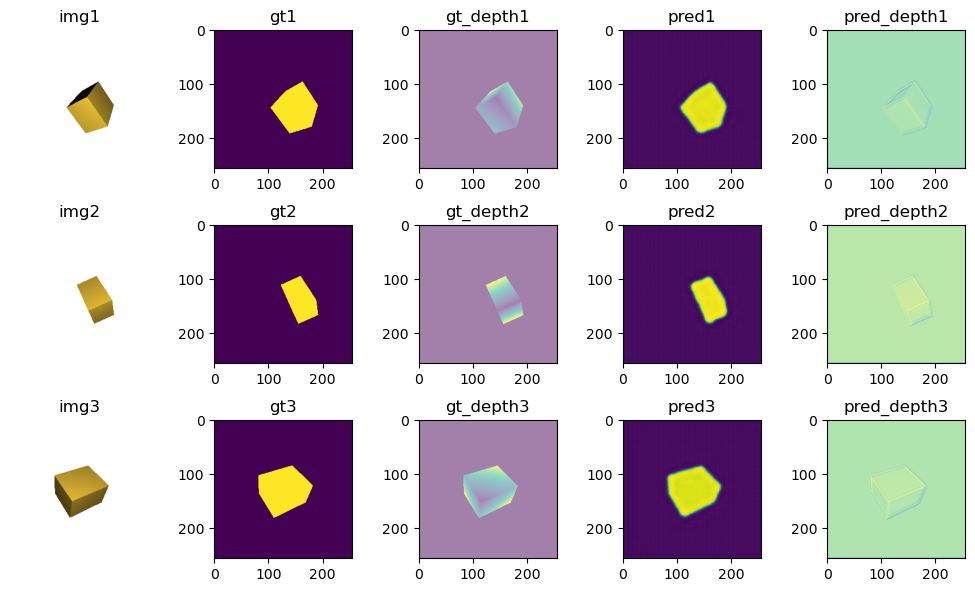

torch.Size([512, 3]) <class 'torch.Tensor'> (1024, 3) <class 'numpy.ndarray'>

3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]


In [5]:
print("\n[Test] 1개의 가상 테스트 데이터 생성 중...")
image_datas, gt_2dDatas, gt_depthDatas, gt_3dDatas = create_data(data_num=1, mode="easy")

# 차원 정렬 및 텐서 변환 (Batch 크기 = 1)
imgs = image_datas[0]
img1 = (torch.from_numpy(imgs[0]).permute(2, 0, 1).float().unsqueeze(0).to(device))
img2 = (torch.from_numpy(imgs[1]).permute(2, 0, 1).float().unsqueeze(0).to(device))
img3 = (torch.from_numpy(imgs[2]).permute(2, 0, 1).float().unsqueeze(0).to(device))

# 손실 함수 계산을 위해 GT도 텐서로 변환 (1, M, 3)
gt_2d_np = gt_2dDatas[0]
gt1 = (torch.from_numpy(gt_2d_np[0]).float().unsqueeze(0).to(device))
gt2 = (torch.from_numpy(gt_2d_np[1]).float().unsqueeze(0).to(device))
gt3 = (torch.from_numpy(gt_2d_np[2]).float().unsqueeze(0).to(device))

# Depth GT도 텐서로 변환 (1, H, W)
gt_depth_np = gt_depthDatas[0]
gt_depth1 = (torch.from_numpy(gt_depth_np[0]).float().unsqueeze(0).to(device))
gt_depth2 = (torch.from_numpy(gt_depth_np[1]).float().unsqueeze(0).to(device))
gt_depth3 = (torch.from_numpy(gt_depth_np[2]).float().unsqueeze(0).to(device))

with torch.no_grad():
    pred_points_tensor_arr = trained_model(img1, img2, img3)  # (1, 1024, 3)
    pred_h1, pred_h2, pred_h3, pred_d1, pred_d2, pred_d3, pred_f1, pred_f2, pred_f3, pred_c1, pred_c2, pred_c3, pred_first_points = pred_points_tensor_arr
    # test_loss = total_loss_fn3(pred_points_tensor_arr, [gt_2dDatas, gt_depthDatas, gt_3dDatas], train=True)
    # coverage = coverage_metric(pred_first_points, gt_3dDatas, threshold=0.02)
    # f_score, precision, recall = fscore_metric(pred_first_points, gt_3dDatas, threshold=0.02)

imgs_vis = [img1, img2, img3]
gts_vis = [gt1, gt2, gt3]
gt_depths_vis = [gt_depth1, gt_depth2, gt_depth3]
preds_vis = [pred_h1, pred_h2, pred_h3]
pred_depths_vis = [pred_d1, pred_d2, pred_d3]

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i in range(3):
    # Image
    img = np.transpose(imgs_vis[i][0].cpu(), (1, 2, 0))

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"img{i+1}")
    axes[i, 0].axis("off")

    # GT
    axes[i, 1].imshow(gts_vis[i][0].cpu().numpy())
    axes[i, 1].set_title(f"gt{i+1}")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].set_ylim(255, 0)

    # GT Depth
    axes[i, 2].imshow(gt_depths_vis[i][0].cpu().numpy(), alpha=0.5)
    axes[i, 2].set_title(f"gt_depth{i+1}")
    axes[i, 2].set_xlim(0, 255)
    axes[i, 2].set_ylim(255, 0)

    # Prediction
    axes[i, 3].imshow(preds_vis[i][0].cpu().numpy())
    axes[i, 3].set_title(f"pred{i+1}")
    axes[i, 3].set_xlim(0, 255)
    axes[i, 3].set_ylim(255, 0)

    # Prediction Depth
    axes[i, 4].imshow(pred_depths_vis[i][0].cpu().numpy(), alpha=0.5)
    axes[i, 4].set_title(f"pred_depth{i+1}")
    axes[i, 4].set_xlim(0, 255)
    axes[i, 4].set_ylim(255, 0)

plt.tight_layout()
plt.show()


def visualize_point_clouds_and_meshes(pred_points_np, gt_points_np):
    """예측된 점군과 정답 점군을 Open3D로 시각화하는 함수입니다.
    pred_points: (N_pred, 3) 예측된 3D 점군 좌표
    gt_points: (N_gt, 3) 정답 3D 점군 좌표
    """

    # === 시각화 구성 ===
    # 1. 정답(GT) 점군 생성 -> 초록색으로 표시
    pcd_gt = o3d.geometry.PointCloud()
    pcd_gt.points = o3d.utility.Vector3dVector(gt_points_np)
    pcd_gt.paint_uniform_color([0, 0.8, 0])  # Green

    # 2. 예측(Pred) 점군 생성 -> 빨간색으로 표시
    pcd_pred = o3d.geometry.PointCloud()
    pcd_pred.points = o3d.utility.Vector3dVector(pred_points_np)
    pcd_pred.paint_uniform_color([1, 0, 0])  # Red

    # 3. 포아송 분포로 입체 도형 생성
    # 면을 생성하기 위해 점들의 법선(Normals)을 먼저 계산합니다.
    pcd_pred.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
    )
    pcd_pred.orient_normals_consistent_tangent_plane(k=15)

    # Poisson Reconstruction 실행 (depth가 높을수록 촘촘하고 디테일해집니다. 기본 8~9 추천)
    mesh_pred, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd_pred, depth=9
    )
    # 포아송 특성상 점군 바깥쪽 영역까지 과도하게 채워진 외곽 쓰레기 면들을 제거합니다.
    # 점들의 밀도가 임계값 이하인 유령 면들을 잘라내어 깔끔하게 마감합니다.
    densities = np.asarray(densities)
    density_mesh_to_remove = densities < np.quantile(densities, 0.05) # 하위 5% 밀도 영역 제거
    mesh_pred.remove_vertices_by_mask(density_mesh_to_remove)

    # 면의 안팎 방향을 바깥쪽(카메라 방향)으로 올바르게 뒤집기
    mesh_pred.orient_triangles() 

    # 입체 셰이딩 및 주홍색 단색 칠하기
    mesh_pred.compute_vertex_normals()
    mesh_pred.paint_uniform_color([0.9, 0.3, 0.3])




    # 3. 두 점군을 나란히 보거나 겹쳐서 확인하기 위해 x축으로 살짝 이동시킨 복사본 생성
    # 왼쪽에는 정답, 오른쪽에는 예측을 두고 겹친 것도 함께 봅니다.
    aabb = pcd_gt.get_axis_aligned_bounding_box()
    extent_x = (aabb.get_extent()[0] * 2.5)  # 도형 X축 크기의 2.5배만큼 떨어뜨려 겹침 방지

    pcd_pred_shifted = o3d.geometry.PointCloud(pcd_pred)
    pcd_pred_shifted.translate([extent_x, 0, 0])  # 오른쪽으로 이동

    pcd_gt_shifted = o3d.geometry.PointCloud(pcd_gt)
    pcd_gt_shifted.translate([-extent_x, 0, 0])  # 왼쪽으로 이동

    mesh_pred_shifted = o3d.geometry.TriangleMesh(mesh_pred)
    mesh_pred_shifted.translate([extent_x * 2, 0, 0])  # 맨 오른쪽 (입체 도형)

    pcd_pred.normals = o3d.utility.Vector3dVector([])          # 두번째 자리용
    pcd_pred_shifted.normals = o3d.utility.Vector3dVector([])  # 세번째 자리용
    print("\n3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]"    )
    o3d.visualization.draw_geometries(
        [pcd_gt_shifted, pcd_gt, pcd_pred, pcd_pred_shifted, mesh_pred_shifted], width=400, height=250
    )

print(pred_first_points[0].shape, type(pred_first_points[0]), gt_3dDatas[0].shape, type(gt_3dDatas[0]))

# print("\n" + "=" * 40)
# print(f"[Test 결과]")
# print(f"-> 전체 배치 학습용 Loss: {test_loss.item():.4f}")
# print("-" * 50)
# print(f"-> 3D 표면 공간 커버리지 (Coverage @ {0.02}): {coverage:.2f}%")
# print(f"-> 3D F-Score 최종 정확도 (F-Score  @ {0.02}): {f_score:.2f}%")
# print("=" * 40)

visualize_point_clouds_and_meshes(np.array(pred_first_points[0].cpu()), gt_3dDatas[0])


In [8]:
print(pred_depths_vis[i][0].cpu().numpy().min())
print(pred_depths_vis[i][0].cpu().numpy().max())

0.07071411
0.31010193


In [9]:
# feat_points1, feat_points2, feat_points3, conn_points1, conn_points2, conn_points3
feat_points_np1 = np.array(pred_f1.view(-1, 3).cpu()).astype(np.float32)
feat_points_np2 = np.array(pred_f2.view(-1, 3).cpu()).astype(np.float32)
feat_points_np3 = np.array(pred_f3.view(-1, 3).cpu()).astype(np.float32)
visualize_point_clouds_and_meshes(feat_points_np1, gt_3dDatas[0])
visualize_point_clouds_and_meshes(feat_points_np2, gt_3dDatas[0])
visualize_point_clouds_and_meshes(feat_points_np3, gt_3dDatas[0])



3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]

3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]

3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]


In [ ]:
def test_reconstruct_model(model, threshold=0.05, mode="easy"):
    """테스트 데이터 1개에 대해 CD Loss와 F-Score 정확도를 계산하고 결과를 시각화합니다."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()  # 평가 모드로 전환 (BatchNorm 등을 고정)

    print("\n[Test] 1개의 가상 테스트 데이터 생성 중...")
    image_datas, gt_2dpoints, gt_depth, gt_3dpoints = create_data(data_num=1, mode="easy")
    
    # 차원 정렬 및 텐서 변환 (Batch 크기 = 1)
    imgs = image_datas[0]
    img1 = (torch.from_numpy(imgs[0]).permute(2, 0, 1).float().unsqueeze(0).to(device))
    img2 = (torch.from_numpy(imgs[1]).permute(2, 0, 1).float().unsqueeze(0).to(device))
    img3 = (torch.from_numpy(imgs[2]).permute(2, 0, 1).float().unsqueeze(0).to(device))

    # 손실 함수 계산을 위해 GT도 텐서로 변환 (1, M, 3)
    gt_points_np = gt_3dpoints[0]
    gt_points_tensor = (
        torch.from_numpy(gt_points_np).float().unsqueeze(0).to(device)
    )

    print("[Test] 모델 피드포워드 및 3D 좌표 예측 중...")
    with torch.no_grad():
        pred_points_tensor_arr = model(img1, img2, img3)  # (1, 1024, 3)
        pred_points_tensor = pred_points_tensor_arr[0][-1]

        # 1. 테스트 데이터에 대한 Loss 계산
        test_loss = total_loss_fn3(pred_points_tensor_arr, [np.array(gt_2dpoints), np.array(gt_depth), np.array(gt_3dpoints)])

        # 2. 3D 정확도 (F-Score) 계산을 위한 거리 매트릭스 계산
        # (1, 1024, 1, 3) - (1, 1, 4096, 3) -> (1024, 4096)
        diff = pred_points_tensor.squeeze(0).unsqueeze(1) - gt_points_tensor.squeeze(0).unsqueeze(0)
        dist_matrix = torch.norm(diff, dim=-1)  # 제곱이 아닌 실제 유클리드 거리 (L2)

        # 예측된 점 각각이 GT와 가장 가까운 거리
        src_to_tgt_dist, _ = torch.min(dist_matrix, dim=1)
        # GT 점 각각이 예측된 점과 가장 가까운 거리
        tgt_to_src_dist, _ = torch.min(dist_matrix, dim=0)

        # 분리형 오차 거리 계산
        cd_precision = torch.mean(src_to_tgt_dist).item()
        cd_recall = torch.mean(tgt_to_src_dist).item()
        # 3. [통일] MMD 기반 공간 표면 커버리지 계산
        coverage = torch.mean((tgt_to_src_dist < threshold).float()).item() * 100

        # 4. [통일] 교정된 3D F-Score 정확도 계산
        precision = torch.mean((src_to_tgt_dist < threshold).float()).item()
        recall = torch.mean((tgt_to_src_dist < threshold).float()).item()

        # 조화평균을 구하여 최종 F-Score(정확도) 산출
        if precision + recall > 0:
            f_score = 2 * (precision * recall) / (precision + recall) * 100
        else:
            f_score = 0.0

    # numpy 변환 (시각화용)
    pred_points_np = pred_points_tensor.squeeze(0).cpu().numpy()

    print("\n" + "=" * 40)
    print(f"[Test 결과]")
    print(f"-> 전체 배치 학습용 Loss: {test_loss.item():.4f}")
    print("-" * 50)
    print(f"-> [정밀도] CD-Precision (예측->정답 평균오차 거리): {cd_precision:.4f}")
    print(f"-> [커버율] CD-Recall    (정답->예측 평균오차 거리): {cd_recall:.4f}")
    print("-" * 50)
    print(f"-> 3D 표면 공간 커버리지 (Coverage @ {threshold}): {coverage:.2f}%")
    print(f"-> 3D F-Score 최종 정확도 (F-Score  @ {threshold}): {f_score:.2f}%")


    print("=" * 40)

    fig, axes = plt.subplots(1, len(imgs), figsize=(10, 4))
    for i, img in enumerate(imgs):
        axes[i].imshow(img)
        axes[i].set_title(f"View {i+1}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

    # === 시각화 구성 ===
    # 1. 정답(GT) 점군 생성 -> 초록색으로 표시
    pcd_gt = o3d.geometry.PointCloud()
    pcd_gt.points = o3d.utility.Vector3dVector(gt_points_np)
    pcd_gt.paint_uniform_color([0, 0.8, 0])  # Green

    # 2. 예측(Pred) 점군 생성 -> 빨간색으로 표시
    pcd_pred = o3d.geometry.PointCloud()
    pcd_pred.points = o3d.utility.Vector3dVector(pred_points_np)
    pcd_pred.paint_uniform_color([1, 0, 0])  # Red



    # 3. 포아송 분포로 입체 도형 생성
    # 면을 생성하기 위해 점들의 법선(Normals)을 먼저 계산합니다.
    pcd_pred.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
    )
    pcd_pred.orient_normals_consistent_tangent_plane(k=15)

    # Poisson Reconstruction 실행 (depth가 높을수록 촘촘하고 디테일해집니다. 기본 8~9 추천)
    mesh_pred, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd_pred, depth=9
    )
    # 포아송 특성상 점군 바깥쪽 영역까지 과도하게 채워진 외곽 쓰레기 면들을 제거합니다.
    # 점들의 밀도가 임계값 이하인 유령 면들을 잘라내어 깔끔하게 마감합니다.
    densities = np.asarray(densities)
    density_mesh_to_remove = densities < np.quantile(densities, 0.05) # 하위 5% 밀도 영역 제거
    mesh_pred.remove_vertices_by_mask(density_mesh_to_remove)

    # 면의 안팎 방향을 바깥쪽(카메라 방향)으로 올바르게 뒤집기
    mesh_pred.orient_triangles() 

    # 입체 셰이딩 및 주홍색 단색 칠하기
    mesh_pred.compute_vertex_normals()
    mesh_pred.paint_uniform_color([0.9, 0.3, 0.3])




    # 3. 두 점군을 나란히 보거나 겹쳐서 확인하기 위해 x축으로 살짝 이동시킨 복사본 생성
    # 왼쪽에는 정답, 오른쪽에는 예측을 두고 겹친 것도 함께 봅니다.
    aabb = pcd_gt.get_axis_aligned_bounding_box()
    extent_x = (aabb.get_extent()[0] * 2.5)  # 도형 X축 크기의 2.5배만큼 떨어뜨려 겹침 방지

    pcd_pred_shifted = o3d.geometry.PointCloud(pcd_pred)
    pcd_pred_shifted.translate([extent_x, 0, 0])  # 오른쪽으로 이동

    pcd_gt_shifted = o3d.geometry.PointCloud(pcd_gt)
    pcd_gt_shifted.translate([-extent_x, 0, 0])  # 왼쪽으로 이동

    mesh_pred_shifted = o3d.geometry.TriangleMesh(mesh_pred)
    mesh_pred_shifted.translate([extent_x * 2, 0, 0])  # 맨 오른쪽 (입체 도형)

    pcd_pred.normals = o3d.utility.Vector3dVector([])          # 두번째 자리용
    pcd_pred_shifted.normals = o3d.utility.Vector3dVector([])  # 세번째 자리용
    print("\n3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]"    )
    o3d.visualization.draw_geometries(
        [pcd_gt_shifted, pcd_gt, pcd_pred, pcd_pred_shifted, mesh_pred_shifted], width=400, height=250
    )

# 2. 테스트 함수 가동
test_reconstruct_model(trained_model, mode="easy")

In [ ]:

# [Test] 1개의 가상 테스트 데이터 생성 중...
# [Test] 모델 피드포워드 및 3D 좌표 예측 중...

# ========================================
# [Test 결과]
# -> 전체 배치 학습용 Loss: 0.0079
# --------------------------------------------------
# -> [정밀도] CD-Precision (예측->정답 평균오차 거리): 0.0581
# -> [커버율] CD-Recall    (정답->예측 평균오차 거리): 0.0558
# --------------------------------------------------
# -> 3D 표면 공간 커버리지 (Coverage @ 0.05): 40.38%
# -> 3D F-Score 최종 정확도 (F-Score  @ 0.05): 42.53%
# ========================================

# 3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측]

In [ ]:
# - [3단계: SimpleNet 방식의 이상 탐지 학습]
# <br> - 진짜 정답(GT Point Cloud) 추출
# <br> - [정상 데이터]로 취급하여 학습
# <br> - 여기에 가우시안 노이즈를 섞어 분포를 비튼 [가짜 불량 데이터] 생성
# <br> - 판별기(Discriminator)가 진짜 정답과 가짜 노이즈 데이터를 구분하도록 학습
